In [ ]:
import pandas as pd
import numpy as np
import re
import sqlite3

In [ ]:
# Read the two raw datasets
gdp_raw = pd.read_json("GDPfinal.json")
suicide_raw = pd.read_csv("suicide.csv")

# Check basic structure
print("GDP shape:", gdp_raw.shape)
print("Suicide shape:", suicide_raw.shape)

print("\nGDP columns:")
print(gdp_raw.columns)

print("\nSuicide columns:")
print(suicide_raw.columns)

display(gdp_raw.head())
display(suicide_raw.head())

GDP shape: (184, 18)
Suicide shape: (18315, 6)

GDP columns:
Index(['Country', 'Population Rank', 'Growth Rate', 'World Percentage',
       'Density', 'Land Area', '2020 Population Rank', '2020 World Percentage',
       '2020 Growth Rate', 'Area', 'Capital City', 'Region', 'Subregion',
       'Anthem', 'Government', 'GDP (IMF)', 'GDP (UN)', 'GDP Per Capita'],
      dtype='object')

Suicide columns:
Index(['iso_code', 'country', 'year', 'sex', 'age_group', 'suicide_rate'], dtype='object')


,Country,Population Rank,Growth Rate,World Percentage,Density,Land Area,2020 Population Rank,2020 World Percentage,2020 Growth Rate,Area,Capital City,Region,Subregion,Anthem,Government,GDP (IMF),GDP (UN),GDP Per Capita
0,Spain,30.0,0.04%,0.60%,92.40,"498,800",30,0.60%,0.04%,"505,992",Madrid,Europe,Southern Europe,Spain,Spain,$1.50 Tn,$1.24 Tn,"$32,019.83"
1,Cyprus,158.0,0.73%,0.02%,130.51,"9,240",158,0.02%,0.73%,"9,251",Nicosia,Europe,Eastern Europe,NaN,NaN,$26.35 Bn,$20.05 Bn,"$21,822.84"
2,Bahrain,152.0,3.68%,0.02%,2224.28,760,152,0.02%,3.68%,765,Manama,Asia,Western Asia,NaN,NaN,$40.71 Bn,$32.18 Bn,"$23,923.13"
3,Bhutan,165.0,1.12%,0.01%,20.10,"38,117",165,0.01%,1.12%,"38,394",Thimphu,Asia,Southern Asia,NaN,NaN,$2.94 Bn,$2.21 Bn,"$3,808.93"
4,Singapore,114.0,0.79%,0.08%,8239.92,700,114,0.08%,0.79%,710,Singapore,Asia,South-Eastern Asia,NaN,NaN,$391.88 Bn,$296.95 Bn,"$66,983.26"


,iso_code,country,year,sex,age_group,suicide_rate
0,AFG,Afghanistan,2000,male,ALL,5.793457
1,AFG,Afghanistan,2000,both,ALL,4.356148
2,AFG,Afghanistan,2000,female,ALL,2.910393
3,AFG,Afghanistan,2001,male,ALL,5.831328
4,AFG,Afghanistan,2001,both,ALL,4.383031


In [ ]:
# Basic audit for GDP dataset
print("GDP missing values:")
print(gdp_raw.isnull().sum())

print("\nGDP duplicate rows:")
print(gdp_raw.duplicated().sum())

print("\nSuicide missing values:")
print(suicide_raw.isnull().sum())

print("\nSuicide duplicate rows:")
print(suicide_raw.duplicated().sum())

print("\nSuicide year range:")
print(suicide_raw["year"].min(), "-", suicide_raw["year"].max())

print("\nSuicide sex values:")
print(suicide_raw["sex"].unique())

print("\nSuicide age group values:")
print(suicide_raw["age_group"].unique())

GDP missing values:
Country                    0
Population Rank            2
Growth Rate                2
World Percentage           2
Density                    0
Land Area                  2
2020 Population Rank       0
2020 World Percentage      0
2020 Growth Rate           0
Area                       0
Capital City               0
Region                     0
Subregion                  0
Anthem                   158
Government               106
GDP (IMF)                  0
GDP (UN)                   0
GDP Per Capita             0
dtype: int64

GDP duplicate rows:
0

Suicide missing values:
iso_code        0
country         0
year            0
sex             0
age_group       0
suicide_rate    0
dtype: int64

Suicide duplicate rows:
0

Suicide year range:
2000 - 2021

Suicide sex values:
['male' 'both' 'female']

Suicide age group values:
['ALL' '20_29' '30_49' '15_19' '70_PLUS' '30_39' '15_29' '60_69' '50_69'
 '50_59' '40_49' '10_19']


In [ ]:
# Convert GDP text values into numeric values
def money_to_number(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip()
    text = text.replace("$", "").replace(",", "")

    if text == "-" or text == "":
        return np.nan

    match = re.match(r"^(-?\d+(?:\.\d*)?)\s*([A-Za-z]+)?$", text)

    if not match:
        return np.nan

    number = float(match.group(1))
    unit = match.group(2)

    if unit == "Tn":
        return number * 1_000_000_000_000
    elif unit == "Bn":
        return number * 1_000_000_000
    elif unit == "Mn":
        return number * 1_000_000
    else:
        return number

In [ ]:
# Make a clean copy of the GDP dataset
gdp_clean = gdp_raw.copy()

# The GDP dataset is treated as 2020 country-level data
gdp_clean["year"] = 2020

# Create a simple country key for matching
gdp_clean["country_key"] = (
    gdp_clean["Country"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert GDP fields from text to numbers
gdp_clean["gdp_imf_usd"] = gdp_clean["GDP (IMF)"].apply(money_to_number)
gdp_clean["gdp_un_usd"] = gdp_clean["GDP (UN)"].apply(money_to_number)
gdp_clean["gdp_per_capita_usd"] = gdp_clean["GDP Per Capita"].apply(money_to_number)

# Keep useful fields only
gdp_clean = gdp_clean[
    [
        "Country",
        "country_key",
        "year",
        "Region",
        "Subregion",
        "gdp_imf_usd",
        "gdp_un_usd",
        "gdp_per_capita_usd"
    ]
]

display(gdp_clean.head())

print("GDP clean shape:", gdp_clean.shape)
print("\nMissing values after cleaning:")
print(gdp_clean.isnull().sum())

,Country,country_key,year,Region,Subregion,gdp_imf_usd,gdp_un_usd,gdp_per_capita_usd
0,Spain,spain,2020,Europe,Southern Europe,1.500000e+12,1.240000e+12,32019.83
1,Cyprus,cyprus,2020,Europe,Eastern Europe,2.635000e+10,2.005000e+10,21822.84
2,Bahrain,bahrain,2020,Asia,Western Asia,4.071000e+10,3.218000e+10,23923.13
3,Bhutan,bhutan,2020,Asia,Southern Asia,2.940000e+09,2.210000e+09,3808.93
4,Singapore,singapore,2020,Asia,South-Eastern Asia,3.918800e+11,2.969500e+11,66983.26


GDP clean shape: (184, 8)

Missing values after cleaning:
Country               0
country_key           0
year                  0
Region                0
Subregion             0
gdp_imf_usd           2
gdp_un_usd            2
gdp_per_capita_usd    0
dtype: int64


In [ ]:
# Filter suicide data to match the 2020 GDP dataset
suicide_2020 = suicide_raw[
    (suicide_raw["year"] == 2020) &
    (suicide_raw["age_group"] == "ALL")
].copy()
name_map = {
    "Cabo Verde": "Cape Verde",
    "Czechia": "Czech Republic",
    "Côte d’Ivoire": "Ivory Coast",
    "Democratic Republic of the Congo": "DR Congo",
    "North Macedonia": "Macedonia",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "Eswatini": "Swaziland",
    "Türkiye": "Turkey",
}
suicide_2020["country"] = suicide_2020["country"].replace(name_map)

# Create a simple country key for matching
suicide_2020["country_key"] = (
    suicide_2020["country"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Make sure suicide rate is numeric
suicide_2020["suicide_rate"] = pd.to_numeric(
    suicide_2020["suicide_rate"],
    errors="coerce"
)

display(suicide_2020.head())

print("Suicide 2020 shape:", suicide_2020.shape)
print("\nSex values:")
print(suicide_2020["sex"].unique())

print("\nMissing values:")
print(suicide_2020.isnull().sum())

,iso_code,country,year,sex,age_group,suicide_rate,country_key
60,AFG,Afghanistan,2020,both,ALL,3.493914,afghanistan
61,AFG,Afghanistan,2020,female,ALL,2.394483,afghanistan
62,AFG,Afghanistan,2020,male,ALL,4.572058,afghanistan
159,AGO,Angola,2020,male,ALL,11.492239,angola
160,AGO,Angola,2020,both,ALL,7.409206,angola


Suicide 2020 shape: (555, 7)

Sex values:
['both' 'female' 'male']

Missing values:
iso_code        0
country         0
year            0
sex             0
age_group       0
suicide_rate    0
country_key     0
dtype: int64


In [ ]:
# Put male, female and both suicide rates into separate columns
suicide_pivot = suicide_2020.pivot_table(
    index=["iso_code", "country", "year", "country_key"],
    columns="sex",
    values="suicide_rate",
    aggfunc="first"
).reset_index()

# Rename columns clearly
suicide_pivot = suicide_pivot.rename(columns={
    "both": "suicide_rate_both",
    "female": "suicide_rate_female",
    "male": "suicide_rate_male"
})

# Calculate gender gap
suicide_pivot["gender_gap"] = (
    suicide_pivot["suicide_rate_male"] - suicide_pivot["suicide_rate_female"]
)

display(suicide_pivot.head())

print("Suicide pivot shape:", suicide_pivot.shape)
print("\nMissing values:")
print(suicide_pivot.isnull().sum())

sex,iso_code,country,year,country_key,suicide_rate_both,suicide_rate_female,suicide_rate_male,gender_gap
0,AFG,Afghanistan,2020,afghanistan,3.493914,2.394483,4.572058,2.177576
1,AGO,Angola,2020,angola,7.409206,3.415952,11.492239,8.076288
2,ALB,Albania,2020,albania,3.355071,2.291795,4.440141,2.148346
3,ARE,United Arab Emirates,2020,united arab emirates,2.377881,0.400705,3.471652,3.070946
4,ARG,Argentina,2020,argentina,8.121802,3.115624,13.206801,10.091178


Suicide pivot shape: (185, 8)

Missing values:
sex
iso_code               0
country                0
year                   0
country_key            0
suicide_rate_both      0
suicide_rate_female    0
suicide_rate_male      0
gender_gap             0
dtype: int64


In [ ]:
# Test merge using country name and year
combined_data = pd.merge(
    gdp_clean,
    suicide_pivot,
    on=["country_key", "year"],
    how="inner"
)

print("GDP rows:", len(gdp_clean))
print("Suicide rows:", len(suicide_pivot))
print("Matched rows before mapping:", len(combined_data))

display(combined_data.head())

GDP rows: 184
Suicide rows: 185
Matched rows before mapping: 176


,Country,country_key,year,Region,Subregion,gdp_imf_usd,gdp_un_usd,gdp_per_capita_usd,iso_code,country,suicide_rate_both,suicide_rate_female,suicide_rate_male,gender_gap
0,Spain,spain,2020,Europe,Southern Europe,1.500000e+12,1.240000e+12,32019.83,ESP,Spain,8.624267,4.518217,12.878482,8.360265
1,Cyprus,cyprus,2020,Europe,Eastern Europe,2.635000e+10,2.005000e+10,21822.84,CYP,Cyprus,3.864847,2.068085,5.631349,3.563264
2,Bahrain,bahrain,2020,Asia,Western Asia,4.071000e+10,3.218000e+10,23923.13,BHR,Bahrain,5.478217,1.179637,8.078285,6.898648
3,Bhutan,bhutan,2020,Asia,Southern Asia,2.940000e+09,2.210000e+09,3808.93,BTN,Bhutan,5.076827,3.408273,6.517589,3.109316
4,Singapore,singapore,2020,Asia,South-Eastern Asia,3.918800e+11,2.969500e+11,66983.26,SGP,Singapore,8.938073,5.419005,12.216388,6.797383


In [ ]:
# === Export the combined dataset as JSON (final storage format) ===

# Perform the final merge on the name-aligned data (should give 176 countries)
combined = pd.merge(
    gdp_clean,
    suicide_pivot,
    on=["country_key", "year"],
    how="inner"
)
print("Final combined rows:", len(combined))   # should be 176

# Export to a single JSON file
combined.to_json(
    "combined_suicide_gdp.json",
    orient="records",
    indent=2,
    force_ascii=False
)
print("Exported combined_suicide_gdp.json")

# Preview the first two records to confirm structure (use this for the screenshot)
import json
with open("combined_suicide_gdp.json") as f:
    data = json.load(f)
print("Total records:", len(data))
print(json.dumps(data[:2], indent=2, ensure_ascii=False))

Final combined rows: 176
Exported combined_suicide_gdp.json
Total records: 176
[
  {
    "Country": "Spain",
    "country_key": "spain",
    "year": 2020,
    "Region": "Europe",
    "Subregion": "Southern Europe",
    "gdp_imf_usd": 1500000000000.0,
    "gdp_un_usd": 1240000000000.0,
    "gdp_per_capita_usd": 32019.83,
    "iso_code": "ESP",
    "country": "Spain",
    "suicide_rate_both": 8.624266997,
    "suicide_rate_female": 4.518217055,
    "suicide_rate_male": 12.87848228,
    "gender_gap": 8.360265225
  },
  {
    "Country": "Cyprus",
    "country_key": "cyprus",
    "year": 2020,
    "Region": "Europe",
    "Subregion": "Eastern Europe",
    "gdp_imf_usd": 26350000000.0,
    "gdp_un_usd": 20050000000.0,
    "gdp_per_capita_usd": 21822.84,
    "iso_code": "CYP",
    "country": "Cyprus",
    "suicide_rate_both": 3.86484692,
    "suicide_rate_female": 2.068084833,
    "suicide_rate_male": 5.63134908,
    "gender_gap": 3.563264247
  }
]


In [ ]:
# Download the JSON file to your computer
from google.colab import files
files.download("combined_suicide_gdp.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 3. Questions and Answers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the final combined dataset
df = pd.read_json("combined_suicide_gdp.json")

# Check the data
print(df.shape)
print(df.columns)
display(df.head())

(176, 14)
Index(['Country', 'country_key', 'year', 'Region', 'Subregion', 'gdp_imf_usd',
       'gdp_un_usd', 'gdp_per_capita_usd', 'iso_code', 'country',
       'suicide_rate_both', 'suicide_rate_female', 'suicide_rate_male',
       'gender_gap'],
      dtype='object')


,Country,country_key,year,Region,Subregion,gdp_imf_usd,gdp_un_usd,gdp_per_capita_usd,iso_code,country,suicide_rate_both,suicide_rate_female,suicide_rate_male,gender_gap
0,Spain,spain,2020,Europe,Southern Europe,1.500000e+12,1.240000e+12,32019.83,ESP,Spain,8.624267,4.518217,12.878482,8.360265
1,Cyprus,cyprus,2020,Europe,Eastern Europe,2.635000e+10,2.005000e+10,21822.84,CYP,Cyprus,3.864847,2.068085,5.631349,3.563264
2,Bahrain,bahrain,2020,Asia,Western Asia,4.071000e+10,3.218000e+10,23923.13,BHR,Bahrain,5.478217,1.179637,8.078285,6.898648
3,Bhutan,bhutan,2020,Asia,Southern Asia,2.940000e+09,2.210000e+09,3808.93,BTN,Bhutan,5.076827,3.408273,6.517589,3.109316
4,Singapore,singapore,2020,Asia,South-Eastern Asia,3.918800e+11,2.969500e+11,66983.26,SGP,Singapore,8.938073,5.419005,12.216388,6.797383


Pearson correlation: 0.1899436476897168
Spearman correlation: 0.23575610829848118


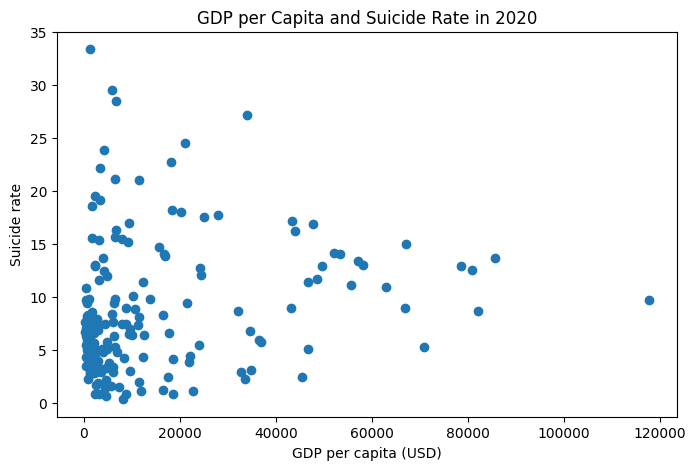

In [ ]:
# Q1: Relationship between GDP per capita and suicide rate

pearson_corr = df["gdp_per_capita_usd"].corr(
    df["suicide_rate_both"],
    method="pearson"
)

spearman_corr = df["gdp_per_capita_usd"].corr(
    df["suicide_rate_both"],
    method="spearman"
)

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df["gdp_per_capita_usd"], df["suicide_rate_both"])
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Suicide rate")
plt.title("GDP per Capita and Suicide Rate in 2020")
plt.show()

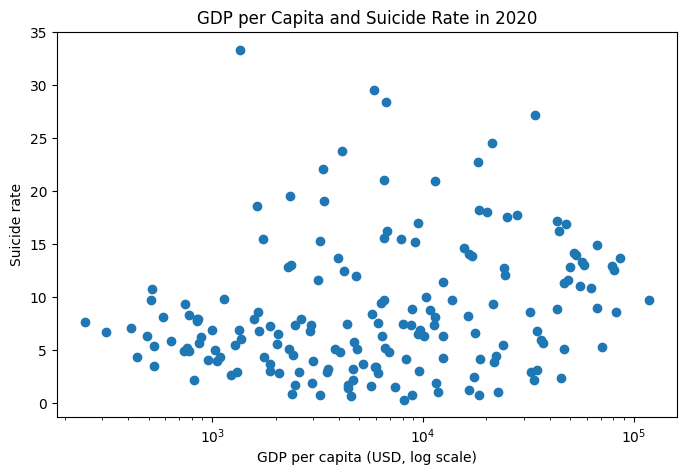

In [ ]:
# Scatter plot with log scale for GDP per capita
plt.figure(figsize=(8, 5))
plt.scatter(df["gdp_per_capita_usd"], df["suicide_rate_both"])
plt.xscale("log")
plt.xlabel("GDP per capita (USD, log scale)")
plt.ylabel("Suicide rate")
plt.title("GDP per Capita and Suicide Rate in 2020")
plt.show()

In [ ]:
# Question 02

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the final combined JSON data store
df = pd.read_json("combined_suicide_gdp.json")

# Check the dataset
print("Shape:", df.shape)
print(df.columns)

display(df.head())

Shape: (176, 14)
Index(['Country', 'country_key', 'year', 'Region', 'Subregion', 'gdp_imf_usd',
       'gdp_un_usd', 'gdp_per_capita_usd', 'iso_code', 'country',
       'suicide_rate_both', 'suicide_rate_female', 'suicide_rate_male',
       'gender_gap'],
      dtype='object')


,Country,country_key,year,Region,Subregion,gdp_imf_usd,gdp_un_usd,gdp_per_capita_usd,iso_code,country,suicide_rate_both,suicide_rate_female,suicide_rate_male,gender_gap
0,Spain,spain,2020,Europe,Southern Europe,1.500000e+12,1.240000e+12,32019.83,ESP,Spain,8.624267,4.518217,12.878482,8.360265
1,Cyprus,cyprus,2020,Europe,Eastern Europe,2.635000e+10,2.005000e+10,21822.84,CYP,Cyprus,3.864847,2.068085,5.631349,3.563264
2,Bahrain,bahrain,2020,Asia,Western Asia,4.071000e+10,3.218000e+10,23923.13,BHR,Bahrain,5.478217,1.179637,8.078285,6.898648
3,Bhutan,bhutan,2020,Asia,Southern Asia,2.940000e+09,2.210000e+09,3808.93,BTN,Bhutan,5.076827,3.408273,6.517589,3.109316
4,Singapore,singapore,2020,Asia,South-Eastern Asia,3.918800e+11,2.969500e+11,66983.26,SGP,Singapore,8.938073,5.419005,12.216388,6.797383


In [ ]:
# Check the key columns needed for Question 2
q2_cols = [
    "Country",
    "gdp_per_capita_usd",
    "suicide_rate_male",
    "suicide_rate_female",
    "gender_gap"
]

display(df[q2_cols].head())

print(df[q2_cols].isnull().sum())

,Country,gdp_per_capita_usd,suicide_rate_male,suicide_rate_female,gender_gap
0,Spain,32019.83,12.878482,4.518217,8.360265
1,Cyprus,21822.84,5.631349,2.068085,3.563264
2,Bahrain,23923.13,8.078285,1.179637,6.898648
3,Bhutan,3808.93,6.517589,3.408273,3.109316
4,Singapore,66983.26,12.216388,5.419005,6.797383


Country                0
gdp_per_capita_usd     0
suicide_rate_male      0
suicide_rate_female    0
gender_gap             0
dtype: int64


In [ ]:
# Recalculate gender gap to confirm the value
df["gender_gap_check"] = df["suicide_rate_male"] - df["suicide_rate_female"]

# Check whether the existing gender_gap is correct
difference = (df["gender_gap"] - df["gender_gap_check"]).abs().max()

print("Maximum difference between gender_gap and recalculated value:", difference)

Maximum difference between gender_gap and recalculated value: 7.105427357601002e-15


In [ ]:
# Define high and low GDP-per-capita groups using quartiles
low_cutoff = df["gdp_per_capita_usd"].quantile(0.25)
high_cutoff = df["gdp_per_capita_usd"].quantile(0.75)

print("Low GDP cutoff:", low_cutoff)
print("High GDP cutoff:", high_cutoff)

# Create GDP group labels
df["gdp_group"] = np.where(
    df["gdp_per_capita_usd"] <= low_cutoff,
    "Low GDP per capita",
    np.where(
        df["gdp_per_capita_usd"] >= high_cutoff,
        "High GDP per capita",
        "Middle"
    )
)

# Check group counts
df["gdp_group"].value_counts()

Low GDP cutoff: 2052.2774999999997
High GDP cutoff: 18416.8675


,count
gdp_group,
Middle,88
High GDP per capita,44
Low GDP per capita,44


In [ ]:
# Compare gender gap between high-GDP and low-GDP countries
q2_summary = (
    df[df["gdp_group"] != "Middle"]
    .groupby("gdp_group")
    .agg(
        countries=("Country", "count"),
        avg_gdp_per_capita=("gdp_per_capita_usd", "mean"),
        avg_suicide_rate=("suicide_rate_both", "mean"),
        avg_male_suicide_rate=("suicide_rate_male", "mean"),
        avg_female_suicide_rate=("suicide_rate_female", "mean"),
        avg_gender_gap=("gender_gap", "mean"),
        median_gender_gap=("gender_gap", "median")
    )
    .reset_index()
)

# Make the table easier to read
q2_summary = q2_summary.round(3)

display(q2_summary)

,gdp_group,countries,avg_gdp_per_capita,avg_suicide_rate,avg_male_suicide_rate,avg_female_suicide_rate,avg_gender_gap,median_gender_gap
0,High GDP per capita,44,44815.633,10.448,15.699,5.249,10.451,8.928
1,Low GDP per capita,44,1046.000,7.240,10.729,3.843,6.886,5.611


In [ ]:
# Extract average gender gaps for interpretation
high_gap = q2_summary.loc[
    q2_summary["gdp_group"] == "High GDP per capita",
    "avg_gender_gap"
].iloc[0]

low_gap = q2_summary.loc[
    q2_summary["gdp_group"] == "Low GDP per capita",
    "avg_gender_gap"
].iloc[0]

gap_difference = high_gap - low_gap

print("Average gender gap in high-GDP-per-capita countries:", high_gap)
print("Average gender gap in low-GDP-per-capita countries:", low_gap)
print("Difference:", round(gap_difference, 3))

Average gender gap in high-GDP-per-capita countries: 10.451
Average gender gap in low-GDP-per-capita countries: 6.886
Difference: 3.565


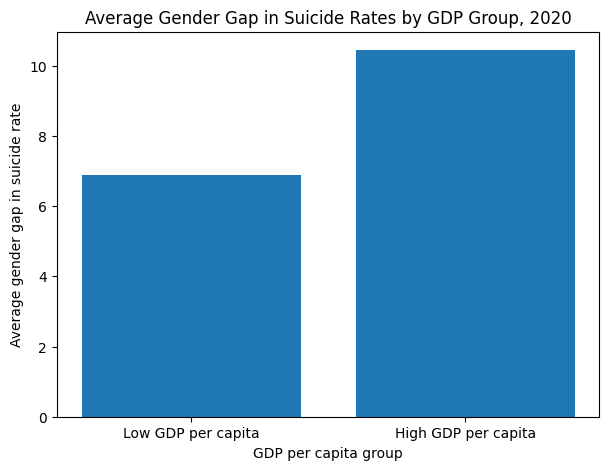

In [ ]:
# Sort the groups so low appears first and high appears second
group_order = ["Low GDP per capita", "High GDP per capita"]

q2_plot = q2_summary.set_index("gdp_group").loc[group_order].reset_index()

# Bar chart of average gender gap
plt.figure(figsize=(7, 5))
plt.bar(q2_plot["gdp_group"], q2_plot["avg_gender_gap"])

plt.xlabel("GDP per capita group")
plt.ylabel("Average gender gap in suicide rate")
plt.title("Average Gender Gap in Suicide Rates by GDP Group, 2020")

plt.show()

/tmp/ipykernel_26226/3374121102.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


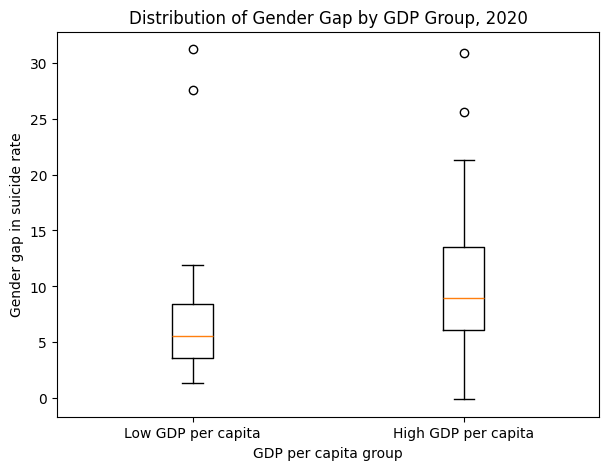

In [ ]:
# Boxplot to compare the distribution of gender gaps
q2_data = df[df["gdp_group"].isin(group_order)]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        q2_data[q2_data["gdp_group"] == "Low GDP per capita"]["gender_gap"],
        q2_data[q2_data["gdp_group"] == "High GDP per capita"]["gender_gap"]
    ],
    labels=group_order
)

plt.xlabel("GDP per capita group")
plt.ylabel("Gender gap in suicide rate")
plt.title("Distribution of Gender Gap by GDP Group, 2020")

plt.show()

In [ ]:
# Countries in the high-GDP group
high_gdp_countries = df[df["gdp_group"] == "High GDP per capita"][
    ["Country", "gdp_per_capita_usd", "suicide_rate_male", "suicide_rate_female", "gender_gap"]
].sort_values("gdp_per_capita_usd", ascending=False)

# Countries in the low-GDP group
low_gdp_countries = df[df["gdp_group"] == "Low GDP per capita"][
    ["Country", "gdp_per_capita_usd", "suicide_rate_male", "suicide_rate_female", "gender_gap"]
].sort_values("gdp_per_capita_usd", ascending=True)

display(high_gdp_countries.head(10))
display(low_gdp_countries.head(10))

,Country,gdp_per_capita_usd,suicide_rate_male,suicide_rate_female,gender_gap
26,Luxembourg,117724.58,13.875074,5.444893,8.430181
72,Switzerland,85584.56,18.130084,9.320152,8.809932
136,Ireland,82058.03,12.130926,5.174922,6.956004
60,Norway,80908.23,17.610859,7.343401,10.267458
42,Iceland,78597.95,18.433648,7.147644,11.286003
105,Qatar,70810.22,6.964545,0.922713,6.041832
13,United States,67063.27,23.588235,6.221038,17.367197
4,Singapore,66983.26,12.216388,5.419005,6.797383
44,Denmark,62937.38,14.987137,6.849638,8.137499
74,Australia,58096.73,19.627532,6.533828,13.093704


,Country,gdp_per_capita_usd,suicide_rate_male,suicide_rate_female,gender_gap
64,South Sudan,249.78,11.840681,3.544993,8.295688
137,Burundi,312.34,9.907213,3.485748,6.421466
125,Malawi,410.93,11.679518,2.682489,8.997030
114,Niger,439.05,5.776548,2.847166,2.929383
70,Madagascar,489.04,9.079709,3.503486,5.576224
79,Central African Republic,514.52,15.844585,3.937920,11.906664
7,Mozambique,521.32,15.731504,6.160765,9.570739
152,Sierra Leone,529.15,6.729484,4.088162,2.641322
17,Afghanistan,531.28,4.572058,2.394483,2.177576
19,DR Congo,585.91,12.757776,3.622760,9.135016


In [ ]:
#Q3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load data
df = pd.read_json('combined_suicide_gdp.json')

# Filter 2020 data
df_2020 = df[
    (df['year'] == 2020) &
    (df['gdp_per_capita_usd'].notna()) &
    (df['suicide_rate_both'].notna())
].copy()

# Use original GDP per capita, no log
X = df_2020[['gdp_per_capita_usd']]
y = df_2020['suicide_rate_both']

# Build linear regression model
model = LinearRegression()
model.fit(X, y)

# Predicted suicide rate
df_2020['expected_suicide_rate'] = model.predict(X)

# Residual = actual - expected
df_2020['residual'] = df_2020['suicide_rate_both'] - df_2020['expected_suicide_rate']

# Absolute residual = how far from the expected relationship
df_2020['abs_residual'] = df_2020['residual'].abs()

# Top 10 countries that deviate most
top10 = df_2020.sort_values('abs_residual', ascending=False).head(10)

top10[['Country', 'gdp_per_capita_usd', 'suicide_rate_both',
       'expected_suicide_rate', 'residual', 'abs_residual']]

In [ ]:
plt.figure(figsize=(12, 7))

# Scatter plot
plt.scatter(
    df_2020['gdp_per_capita_usd'],
    df_2020['suicide_rate_both'],
    alpha=0.6
)

# Regression line
x_line = np.linspace(
    df_2020['gdp_per_capita_usd'].min(),
    df_2020['gdp_per_capita_usd'].max(),
    100
)

y_line = model.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, color='red')

# Label top 10 deviations
for i, row in top10.iterrows():
    plt.text(
        row['gdp_per_capita_usd'],
        row['suicide_rate_both'],
        row['Country'],
        fontsize=9
    )

plt.title('GDP per Capita vs Suicide Rate in 2020')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Suicide Rate')
plt.show()